### LangChain


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

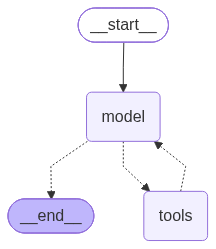

In [2]:
from pydantic_core.core_schema import model_field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")

def get_weather(city:str)-> str:
    """Get the weathre for a city."""
    return f"The weather in {city} is sunny."

agent=create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant.",
)
agent


In [ ]:
#Run the Agent
response=agent.invoke({"messages":[{
    "role":"user",
    "content":"What is capital of India ??"
}]})

ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [ ]:
from langchain_core.messages import content
response["messages"][-1] 

AIMessage(content=[{'type': 'text', 'text': 'The capital of India is New Delhi.', 'extras': {'signature': 'ErACCq0CARFNMg8g0gayTGJydylwvbq4mj0+n60KZNAdqBUg9OXCh5FawzljyQQs3v0v90RQL02kfaX5vPkHZ6Dm4MdGMp2vsXxH81Ku98/6TNIhG+nm4UAU+jof/Uve3pw+uB50QeLfidDA8IUZo53NzkWjhg4+0PQKTkvSmkMsxIST4G3MDBB7849CRUIopvXv9sNhf963n/w3aboc2za53867MvbvqKGei2Pf/sV2ErGNKEkMa/e8MWPZK/KdSQVF+nnltsgjazZscu7f4sDEilGZ1y2MrvNSqOpHG61qymoga2hFtW2zn6lsPGrMcVmGwtiz+Q4IzhVwWbKnuPOFvkkGfANtUZNxWTbVKtQMGSCaSzjNAmfCpxTp3NxBXQelZPI+pgRoILWSxQES5Kn12A=='}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ff980-9dc9-7793-8489-ece760e713ce-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 55, 'total_tokens': 114, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 47}})

### GROQ MODEL INTEGRATION 


In [5]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

model=init_chat_model("groq:llama-3.1-8b-instant")
response=model.invoke("Joke on ML")
print(response.content)


Why did the Machine Learning model go to therapy?

Because it was struggling to generalize its emotions.


### STREAM TECHNIQUE


In [6]:
for chunk in model.stream("Write me a 500 words paragraph on ML"):
    print(chunk.text,end=" ", flush=True)

 Machine  learning  ( ML )  is  a  subset  of  artificial  intelligence  ( AI )  that  involves  the  use  of  algorithms  and  statistical  models  to  enable  computers  to  learn  from  data ,  make  decisions ,  and  improve  their  performance  on  a  specific  task  without  being  explicitly  programmed .  The  core  idea  behind  ML  is  to  enable  machines  to  recognize  patterns ,  classify  objects ,  and  make  predictions  based  on  the  data  they  are  trained  on ,  allowing  them  to  learn  from  experience  and  improve  over  time .  The  field  of  ML  has  witnessed  significant  advancements  in  recent  years ,  driven  by  the  availability  of  large  amounts  of  data ,  the  development  of  powerful  computing  architectures ,  and  the  emergence  of  new  algorithms  and  techniques .

 At  its  core ,  ML  involves  the  use  of  mathematical  models  to  analyze  and  interpret  data ,  which  can  be  categorized  into  two  main  types :  supervise

### BATCHING TECHNIQUE

In [ ]:
response=model.batch(
    [
        "Why do parrots have colorful feathers ?",
        "How do airplanes fly ?",
        "What is quantum computting ?"
    ]
)
for response in response:
    print(response)

content="Parrots have colorful feathers due to several reasons:\n\n1. **Communication and Attraction**: Vibrant colors play a significant role in parrots' social behavior, helping them communicate with each other, attract mates, and establish dominance. Different species have distinct color patterns, which serve as visual cues for these purposes.\n\n2. **Warning Signals**: Some parrot species display bright colors to warn potential predators of their toxicity or distastefulness. For example, certain parrot species have brightly colored beaks or feathers that indicate their presence of a chemical defense mechanism, which can deter predators.\n\n3. **Camouflage and Blend-in**: Although it may seem counterintuitive, some parrots use their bright colors to blend in with their surroundings. For example, a parrot with bright blue or green feathers might use these colors to match the foliage of its native rainforest environment, making it less noticeable to predators.\n\n4. **Mate Selection**